In [ ]:
import sys, os
from pathlib import Path
sys.path.insert(0, os.path.expanduser('~'))
file_path = Path("~/mpl_theme.py").expanduser()
if file_path.is_file():
    import mpl_theme; mpl_theme.apply();
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import numpy as np
import pandas as pd

import glob
import pickle

from utils import *


[mpl_theme] applied 'CMU Sans Serif' with custom color cycle.


/mnt/md0/jjusuf/miniconda3/envs/bild2/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def get_durations(profile):
    durations = []

    profile = np.asarray(profile)
    n = len(profile)
    
    i = 0
    while i < n:
        if profile[i] == 1:
            start = i
            while i < n and profile[i] == 1:
                i += 1
            end = i  # exclusive
            
            lifetime = end - start
            
            # censored if touching either boundary
            censored = (start == 0) or (end == n)
            
            durations.append(lifetime)
        else:
            i += 1
    
    return durations

def extract_lifetimes(tracks):
    """
    tracks: list of 1D lists/arrays of 0/1
    
    Returns:
        durations: list of lifetimes
        events: list of booleans (True = observed, False = censored)
    """
    durations = []
    events = []
    
    for track in tracks:
        track = np.asarray(track)
        n = len(track)
        
        i = 0
        while i < n:
            if track[i] == 1:
                start = i
                while i < n and track[i] == 1:
                    i += 1
                end = i  # exclusive
                
                lifetime = end - start
                
                # censored if touching either boundary
                censored = (start == 0) or (end == n)
                
                durations.append(lifetime)
                events.append(not censored)
            else:
                i += 1
    
    return np.array(durations), np.array(events)

def kaplan_meier(durations, events):
    """
    Compute Kaplan-Meier survival curve.
    
    Returns:
        times: unique event times
        survival: survival probability at each time
    """
    order = np.argsort(durations)
    durations = durations[order]
    events = events[order]
    
    unique_times = np.unique(durations)
    
    n = len(durations)
    at_risk = n
    survival = 1.0
    
    times = []
    surv_probs = []
    
    for t in unique_times:
        mask = durations == t
        d_i = np.sum(events[mask])      # observed events
        c_i = np.sum(~events[mask])     # censored
        
        if at_risk > 0:
            if d_i > 0:
                survival *= (1 - d_i / at_risk)
                times.append(t)
                surv_probs.append(survival)
        
        at_risk -= (d_i + c_i)
    
    return np.array(times), np.array(surv_probs)

def median_survival(times, survival):
    """
    Median survival = first time S(t) <= 0.5
    """
    if len(survival) == 0:
        return np.nan
    
    below = np.where(survival <= 0.5)[0]
    if len(below) == 0:
        return np.inf  # never drops below 0.5
    
    return times[below[0]]

def km_median_lifetime(tracks):
    durations, events = extract_lifetimes(tracks)
    times, survival = kaplan_meier(durations, events)
    return median_survival(times, survival), times, survival


In [4]:
save_folder = '/mnt/md0/jjusuf/bild/synEP_bild/output/bild_profiles/340kb_Ce_Cp_None_initial_dE_2.0'

filenames = [os.path.basename(fn) for fn in glob.glob(os.path.join(save_folder,'*'))]
filenames = [fn for fn in filenames if 'original' in fn]

profile_info = []
for fn in filenames:
    track_name, suffix = fn.split('_bild_result_frame_')
    frames_str = suffix[:-4]
    start_frame, end_frame = frames_str.split('_to_')
    start_frame = int(start_frame)
    end_frame = int(end_frame)
    profile_info.append({'track_name': track_name,
                         'start_frame': start_frame,
                         'end_frame': end_frame,
                         'filename': fn})
    
profile_info = pd.DataFrame(profile_info)
profile_info = profile_info.sort_values(['track_name', 'start_frame'])
profile_info.index = np.arange(len(profile_info))

track_names = np.unique(profile_info['track_name'])

max_unchopped_traj_len = np.max(profile_info['end_frame'])

# make matrix to store inferences; store multiple inferences along 3rd dimension
inferences = np.zeros((len(track_names), max_unchopped_traj_len, 2), dtype='int8') * np.nan
dist_from_end = np.zeros(inferences.shape, dtype='int') * np.nan

dE = 2
for track_name_idx in range(len(track_names)):
    track_name = track_names[track_name_idx]
    profiles_this_track = profile_info.loc[profile_info['track_name']==track_name]
    for i in range(len(profiles_this_track)):
        track_name, start_frame, end_frame, fn = profiles_this_track.iloc[i]
        bild_result = pickle.load(open(os.path.join(save_folder, fn), 'rb'))
        best_profile = bild_result.best_profile(dE=dE)
        best_profile = np.array(list(best_profile)).astype('int8')
        best_profile = pd.Series(best_profile, index=np.arange(start_frame, end_frame))
        for frame_num in range(start_frame, end_frame):
            k = 0
            while not np.isnan(inferences[track_name_idx, frame_num, k]):
                k += 1
                if k > inferences.shape[2]:
                    raise RuntimeError('3rd dimension of inferences not large enough!')
            inferences[track_name_idx, frame_num, k] = best_profile[frame_num]
            dist_from_end[track_name_idx, frame_num, k] = min(frame_num-start_frame, end_frame-frame_num)

final_inferences = np.zeros((inferences.shape[0], inferences.shape[1])) * np.nan
for track_name_idx in range(len(track_names)):
    for frame_num in range(max_unchopped_traj_len):
        inf1 = inferences[track_name_idx, frame_num, 0]
        inf2 = inferences[track_name_idx, frame_num, 1]
        if np.isnan(inf1) and np.isnan(inf2):
            inf = np.nan
        elif np.isnan(inf2):
            inf = inf1
        elif inf1 != inf2:
            if dist_from_end[track_name_idx, frame_num, 0] > dist_from_end[track_name_idx, frame_num, 1]:
                inf = inf1
            else:
                inf = inf2
        else:
            inf = inf1  # doesn't matter, they will be the same
        final_inferences[track_name_idx, frame_num] = inf


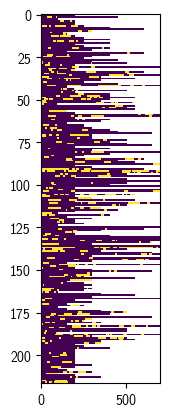

In [ ]:
plt.imshow(final_inferences, aspect=10, interpolation='nearest');


In [6]:
condition = '340kb_Ce_Cp_None'
traj_len = 100

original_trajs_nl, downsampled_trajs_nl = get_original_downsampled_trajs(condition, min_traj_len=traj_len, print_output=False)
data_list_original = [np.array(traj) for traj in original_trajs_nl]
data_list_downsampled = [np.array(traj) for traj in downsampled_trajs_nl]


In [ ]:
i = 50
names_parts = track_names[i].split('_')
track_type = names_parts[0]  # original or downsampled
track_num = int(names_parts[2])
if track_type == 'original':
    traj = data_list_original[track_num]
elif track_type == 'downsampled':
    traj = data_list_downsampled[track_num]
else:
    raise ValueError('track_type must be "original" or "downsampled"')

dist_3d = np.sqrt(np.sum(np.square(traj), 1))
profile = final_inferences[i,:]
profile = profile[:np.where(~np.isnan(profile))[0][-1] + 1]  # remove trailing NaNs

t_minutes = np.arange(len(dist_3d)) * 30/60
extent_L = t_minutes[0]-0.25
extent_R = t_minutes[-1]+0.25


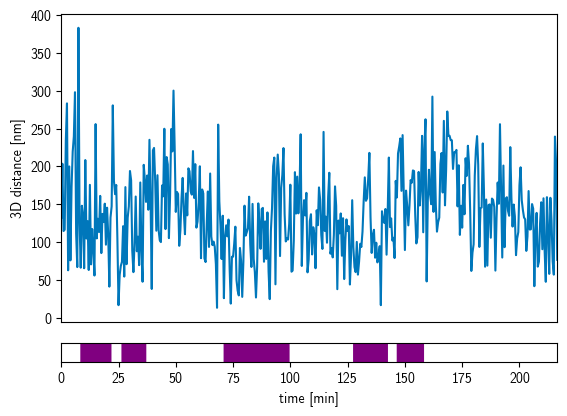

In [8]:
cmap = LinearSegmentedColormap.from_list("white_purple", ["white", "purple"])

fig, axs = plt.subplots(2, 1, gridspec_kw={'height_ratios': [5, 1], 'hspace': 0})
axs[0].plot(t_minutes, dist_3d*1000)
axs[0].set_xlim(t_minutes[0], t_minutes[-1])
axs[0].set_ylabel('3D distance [nm]');
axs[0].set_xticks([])
axs[1].imshow(profile.reshape((1, len(profile))), aspect=len(profile)/50, extent=[extent_L, extent_R, 0, 1], cmap=cmap)
axs[1].set_xlim(t_minutes[0], t_minutes[-1])
axs[1].set_yticks([]);
axs[1].set_xlabel('time [min]');


In [ ]:
# Algorithm 4 in Fbn2 SI
num_trajs = len(final_inferences)
bootstrap_dist = []

for bootstrap_repeat in range(1000):
    looped_frames = 0
    total_frames = 0
    for repeat in range(num_trajs):
        i = np.random.choice(np.arange(num_trajs))
        traj = final_inferences[i,:]
        looped_frames += np.sum(traj==1)
        total_frames += np.sum(np.logical_or(traj==0,traj==1))
    floop = looped_frames / total_frames
    bootstrap_dist.append(floop)


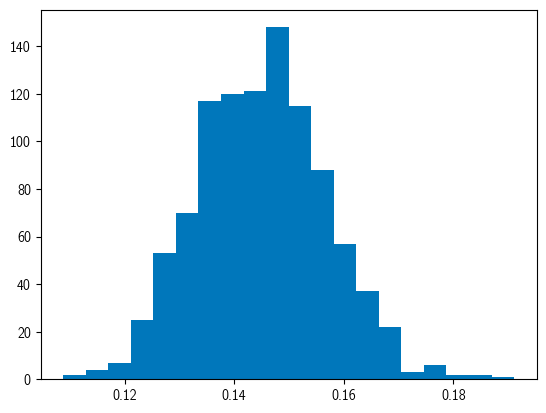

In [105]:
plt.hist(bootstrap_dist, 20);